# dispel4py Agentic AI: simple and multi workflows with traces

This compact Colab notebook runs the two agentic sensor workflows using dispel4py monitoring:

- **Simple:** one stateful agent processes six events.
- **Multi:** a multiprocessing-safe graph processes 100 events with 16 worker processes.

Each run produces two kinds of evidence:

1. **Agent traces** (`*.jsonl`): final decisions, tool calls/results, worker IDs and audit messages.
2. **dispel4py monitoring** (`results/...`): per-PE, per-instance and per-iteration timing CSVs, graph JSON and graph PNGs.

Run the cells from top to bottom. The LLM calls use your OpenAI API account and may incur API charges.


## 1. Install everything

In [1]:
# Install the current d4py repository because it contains timed_simple/timed_multi.
%cd /content
!rm -rf /content/d4py
!git clone -q https://github.com/StreamingFlow/d4py.git /content/d4py
%pip uninstall -y -q stream-d4py stream_d4py dispel4py
%pip install -qU pip setuptools wheel
%pip install -q mpi4py openai pandas matplotlib
%pip install -q -e /content/d4py

from pathlib import Path
Path('/content/results').mkdir(exist_ok=True)
print('Installation complete.')


/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 17.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 84.0.0 which is incompatible.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for stream_d4py (pyproject.toml) ... done
Installation complete.


## 2. Add the API key

The key is entered without being displayed and remains in this Colab runtime. Change `OPENAI_MODEL` if needed.

In [2]:
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI API key: ")
os.environ.setdefault("OPENAI_MODEL", "gpt-5-mini")
print("Model:", os.environ["OPENAI_MODEL"])


Paste your OpenAI API key: ··········
Model: gpt-5-mini


## 3. Simple agentic workflow

Create the six-event input dataset and the stateful agent workflow.

In [3]:
    import json

    sensor_data = [
    {
        "sensor_id": "sensor-001",
        "zone": "north",
        "timestamp": "2026-08-06T09:00:00Z",
        "temperature": 21.8,
        "humidity": 42.0,
        "battery": 83,
        "diagnostic_note": "Routine reading. Signal is stable."
    },
    {
        "sensor_id": "sensor-002",
        "zone": "north",
        "timestamp": "2026-08-06T09:01:00Z",
        "temperature": 22.0,
        "humidity": 43.0,
        "battery": 79,
        "diagnostic_note": "Routine reading from a neighbouring sensor."
    },
    {
        "sensor_id": "sensor-001",
        "zone": "north",
        "timestamp": "2026-08-06T09:10:00Z",
        "temperature": 22.2,
        "humidity": 44.0,
        "battery": 82,
        "diagnostic_note": "Two packets were lost after a brief network interruption. The connection has returned."
    },
    {
        "sensor_id": "sensor-003",
        "zone": "south",
        "timestamp": "2026-08-06T09:12:00Z",
        "temperature": 20.9,
        "humidity": 46.0,
        "battery": 5,
        "diagnostic_note": "Reading is plausible but battery is very low."
    },
    {
        "sensor_id": "sensor-004",
        "zone": "south",
        "timestamp": "2026-08-06T09:14:00Z",
        "temperature": 19.7,
        "humidity": 88.0,
        "battery": 72,
        "diagnostic_note": "A technician heard intermittent buzzing and is unsure whether moisture entered the enclosure."
    },
    {
        "sensor_id": "sensor-002",
        "zone": "north",
        "timestamp": "2026-08-06T09:16:00Z",
        "temperature": 37.5,
        "humidity": 43.0,
        "battery": 78,
        "diagnostic_note": "Sudden temperature increase. The sensor reports that calibration may have drifted."
    }
]

    with open("sensor_data_agentic.json", "w", encoding="utf-8") as handle:
        json.dump(sensor_data, handle, indent=2)

    print("Created sensor_data_agentic.json")
    print("Number of readings:", len(sensor_data))


Created sensor_data_agentic.json
Number of readings: 6


In [4]:
%%writefile sensor_workflow_agentic.py
from collections import defaultdict, deque
from datetime import datetime, timezone
from dispel4py.base import ConsumerPE, GenericPE, IterativePE, ProducerPE
from dispel4py.workflow_graph import WorkflowGraph
from openai import OpenAI
import json
import os


INPUT_FILE = "sensor_data_agentic.json"
OUTPUT_FILE = "agentic_sensor_results.jsonl"


def utc_now():
    return datetime.now(timezone.utc).isoformat()


class ReadSensorDataPE(ProducerPE):
    """Read the JSON file and emit one enriched event at a time."""

    def __init__(self):
        super().__init__()

    def _process(self, inputs):
        file_path = inputs["input"]

        with open(file_path, "r", encoding="utf-8") as handle:
            records = json.load(handle)

        for record in records:
            event = {
                "sensor_id": record["sensor_id"],
                "zone": record["zone"],
                "timestamp": record["timestamp"],
                "temperature": float(record["temperature"]),
                "humidity": float(record["humidity"]),
                "battery": int(record["battery"]),
                "diagnostic_note": record["diagnostic_note"],
                "audit": [
                    f"{utc_now()} ReadSensorDataPE emitted "
                    f"{record['sensor_id']}."
                ],
            }
            self.write("output", event)


class NormalizeDataPE(IterativePE):
    """Retain the familiar deterministic normalisation step."""

    def __init__(self):
        super().__init__()

    def _process(self, data):
        result = dict(data)
        result["normalized_temperature"] = result["temperature"] / 40.0
        result["audit"] = list(result["audit"]) + [
            f"{utc_now()} NormalizeDataPE normalised the temperature."
        ]
        return result


class DeterministicPrecheckPE(GenericPE):
    """
    Apply hard rules before the LLM is considered.

    This PE is not the LLM agent. It is a deterministic safety gate.
    """

    def __init__(self):
        super().__init__()
        self._add_input("input")
        self._add_output("resolved")
        self._add_output("needs_agent")

    def _process(self, inputs):
        event = dict(inputs["input"])
        audit = list(event["audit"])

        if event["battery"] < 10:
            audit.append(
                f"{utc_now()} DeterministicPrecheckPE selected maintenance "
                "because battery was below 10%."
            )
            return {
                "resolved": {
                    **event,
                    "action": "maintenance",
                    "reason": (
                        f"Battery is {event['battery']}%, below the fixed "
                        "10% maintenance threshold."
                    ),
                    "decision_source": "deterministic_rule",
                    "tool_trace": [],
                    "audit": audit,
                }
            }

        if event["temperature"] < -40 or event["temperature"] > 85:
            audit.append(
                f"{utc_now()} DeterministicPrecheckPE selected human_review "
                "because temperature was outside the fixed plausible range."
            )
            return {
                "resolved": {
                    **event,
                    "action": "human_review",
                    "reason": (
                        f"Temperature {event['temperature']}°C is outside "
                        "the fixed -40°C to 85°C range."
                    ),
                    "decision_source": "deterministic_rule",
                    "tool_trace": [],
                    "audit": audit,
                }
            }

        audit.append(
            f"{utc_now()} No hard rule applied; event sent to "
            "LLMSensorAgentPE."
        )
        return {"needs_agent": {**event, "audit": audit}}


class LLMSensorAgentPE(IterativePE):
    """
    A stateful, tool-using agent implemented inside one dispel4py PE.

    The agent can inspect evidence, invoke bounded Python tools, observe their
    results, and continue until it submits a final decision.
    """

    FINAL_ACTIONS = {
        "accept",
        "retry",
        "maintenance",
        "notify_operator",
        "human_review",
    }

    EVIDENCE_TOOLS = {
        "inspect_previous_readings",
        "compare_neighbouring_sensors",
        "request_another_measurement",
    }

    def __init__(
        self,
        neighbour_map,
        model="gpt-5-mini",
        history_size=5,
        max_rounds=6,
    ):
        super().__init__()
        self.neighbour_map = neighbour_map
        self.model = model
        self.history_size = history_size
        self.max_rounds = max_rounds

        self.client = None
        self.history = defaultdict(lambda: deque(maxlen=history_size))
        self.latest_by_sensor = {}

        # These collections simulate external systems.
        self.measurement_requests = []
        self.maintenance_tickets = []
        self.operator_notifications = []
        self.human_review_queue = []

        self.tools = self._build_tools()

    def preprocess(self):
        if not os.environ.get("OPENAI_API_KEY"):
            raise RuntimeError(
                "OPENAI_API_KEY is missing. Run the API-key cell first."
            )
        self.client = OpenAI()

    def _build_tools(self):
        return [
            {
                "type": "function",
                "name": "inspect_previous_readings",
                "description": (
                    "Inspect up to five recent readings from the current "
                    "sensor before deciding."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "sensor_id": {"type": "string"},
                        "limit": {
                            "type": "integer",
                            "minimum": 1,
                            "maximum": 5,
                        },
                    },
                    "required": ["sensor_id", "limit"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "compare_neighbouring_sensors",
                "description": (
                    "Compare the current reading with the most recent readings "
                    "from configured neighbouring sensors."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "sensor_id": {"type": "string"},
                    },
                    "required": ["sensor_id"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "request_another_measurement",
                "description": (
                    "Create a simulated request for another measurement when "
                    "a temporary communication or sampling issue is suspected."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "sensor_id": {"type": "string"},
                        "reason": {"type": "string"},
                    },
                    "required": ["sensor_id", "reason"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "create_maintenance_ticket",
                "description": (
                    "Create a simulated maintenance ticket for likely "
                    "hardware, battery, calibration, or enclosure problems."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "sensor_id": {"type": "string"},
                        "reason": {"type": "string"},
                        "priority": {
                            "type": "string",
                            "enum": ["low", "medium", "high"],
                        },
                    },
                    "required": ["sensor_id", "reason", "priority"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "notify_operator",
                "description": (
                    "Create a simulated operator notification for an event "
                    "that should be visible to operations staff."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "sensor_id": {"type": "string"},
                        "message": {"type": "string"},
                        "severity": {
                            "type": "string",
                            "enum": ["info", "warning", "critical"],
                        },
                    },
                    "required": ["sensor_id", "message", "severity"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "escalate_to_human",
                "description": (
                    "Create a simulated human-review item for ambiguous, "
                    "contradictory, or safety-relevant cases."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "sensor_id": {"type": "string"},
                        "reason": {"type": "string"},
                    },
                    "required": ["sensor_id", "reason"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "submit_final_decision",
                "description": (
                    "Finish the agent loop by submitting exactly one final "
                    "bounded action and a concise reason."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "action": {
                            "type": "string",
                            "enum": [
                                "accept",
                                "retry",
                                "maintenance",
                                "notify_operator",
                                "human_review",
                            ],
                        },
                        "reason": {"type": "string"},
                    },
                    "required": ["action", "reason"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
        ]

    # ----------------------- deterministic tools -----------------------

    def inspect_previous_readings(self, sensor_id, limit, current):
        previous = list(self.history[sensor_id])[-limit:]
        return {
            "sensor_id": sensor_id,
            "count": len(previous),
            "previous_readings": previous,
            "current_reading_excluded": True,
        }

    def compare_neighbouring_sensors(self, sensor_id, current):
        neighbours = []

        for neighbour_id in self.neighbour_map.get(sensor_id, []):
            latest = self.latest_by_sensor.get(neighbour_id)
            if latest:
                neighbours.append(
                    {
                        "sensor_id": neighbour_id,
                        "timestamp": latest["timestamp"],
                        "temperature": latest["temperature"],
                        "humidity": latest["humidity"],
                    }
                )

        differences = [
            {
                "sensor_id": item["sensor_id"],
                "temperature_difference": round(
                    current["temperature"] - item["temperature"], 2
                ),
                "humidity_difference": round(
                    current["humidity"] - item["humidity"], 2
                ),
            }
            for item in neighbours
        ]

        return {
            "sensor_id": sensor_id,
            "neighbours_found": len(neighbours),
            "neighbour_readings": neighbours,
            "differences_from_current": differences,
        }

    def request_another_measurement(self, sensor_id, reason, current):
        request = {
            "request_id": f"RM-{len(self.measurement_requests) + 1:04d}",
            "sensor_id": sensor_id,
            "reason": reason,
            "created_at": utc_now(),
            "status": "simulated",
        }
        self.measurement_requests.append(request)
        return request

    def create_maintenance_ticket(
        self, sensor_id, reason, priority, current
    ):
        ticket = {
            "ticket_id": f"MT-{len(self.maintenance_tickets) + 1:04d}",
            "sensor_id": sensor_id,
            "priority": priority,
            "reason": reason,
            "created_at": utc_now(),
            "status": "simulated",
        }
        self.maintenance_tickets.append(ticket)
        return ticket

    def notify_operator(self, sensor_id, message, severity, current):
        notification = {
            "notification_id": (
                f"OP-{len(self.operator_notifications) + 1:04d}"
            ),
            "sensor_id": sensor_id,
            "severity": severity,
            "message": message,
            "created_at": utc_now(),
            "status": "simulated",
        }
        self.operator_notifications.append(notification)
        return notification

    def escalate_to_human(self, sensor_id, reason, current):
        review = {
            "review_id": f"HR-{len(self.human_review_queue) + 1:04d}",
            "sensor_id": sensor_id,
            "reason": reason,
            "created_at": utc_now(),
            "status": "simulated",
        }
        self.human_review_queue.append(review)
        return review

    def _execute_tool(self, name, arguments, current):
        tool_map = {
            "inspect_previous_readings": self.inspect_previous_readings,
            "compare_neighbouring_sensors": (
                self.compare_neighbouring_sensors
            ),
            "request_another_measurement": (
                self.request_another_measurement
            ),
            "create_maintenance_ticket": (
                self.create_maintenance_ticket
            ),
            "notify_operator": self.notify_operator,
            "escalate_to_human": self.escalate_to_human,
        }

        if name not in tool_map:
            raise ValueError(f"Tool is not permitted: {name}")

        return tool_map[name](current=current, **arguments)

    # -------------------------- agent loop -----------------------------

    def _process(self, event):
        if self.client is None:
            self.preprocess()

        current = dict(event)
        audit = list(current["audit"])
        tool_trace = []
        final_decision = None

        instructions = """
You are LLMSensorAgent, a bounded IoT sensor agent inside a dispel4py
streaming workflow.

Your goal is to assess one sensor event safely.

You may gather evidence by inspecting previous readings, comparing
neighbouring sensors, or requesting another measurement. You may also create
a maintenance ticket, notify an operator, or escalate to a human.

Rules:
- Never invent or modify measurements.
- Prefer deterministic tool evidence over speculation.
- Use at least one evidence-gathering tool before accepting an event that
  contains a warning, uncertainty, packet loss, moisture, buzzing, drift, or
  another possible fault.
- Create a maintenance ticket only for likely equipment, enclosure, battery,
  or calibration problems.
- Escalate ambiguous or safety-relevant cases to a human.
- Finish by calling submit_final_decision.
- If you request another measurement, the final action should normally be
  retry.
- If you create a maintenance ticket, the final action must be maintenance.
- If you escalate to a human, the final action must be human_review.
"""

        first_input = (
            "Assess this sensor event:\n"
            + json.dumps(
                {
                    "sensor_id": current["sensor_id"],
                    "zone": current["zone"],
                    "timestamp": current["timestamp"],
                    "temperature": current["temperature"],
                    "normalized_temperature": (
                        current["normalized_temperature"]
                    ),
                    "humidity": current["humidity"],
                    "battery": current["battery"],
                    "diagnostic_note": current["diagnostic_note"],
                },
                indent=2,
            )
        )

        try:
            # Keep the complete conversation locally. This is compatible with
            # OpenAI organisations that use Zero Data Retention because the
            # workflow does not rely on previous_response_id.
            conversation = [
                {
                    "role": "user",
                    "content": first_input,
                }
            ]

            for round_number in range(1, self.max_rounds + 1):
                response = self.client.responses.create(
                    model=self.model,
                    instructions=instructions,
                    input=conversation,
                    tools=self.tools,
                    tool_choice="auto",
                    store=False,
                )

                calls = [
                    item
                    for item in response.output
                    if getattr(item, "type", None) == "function_call"
                ]

                if not calls:
                    raise RuntimeError(
                        "The model returned no tool call or final decision."
                    )

                # Preserve the model output locally so the next request can see
                # the function calls without server-side response storage.
                conversation.extend(
                    [
                        item.model_dump(exclude_none=True)
                        if hasattr(item, "model_dump")
                        else item
                        for item in response.output
                    ]
                )

                tool_outputs = []

                for call in calls:
                    arguments = json.loads(call.arguments)

                    if call.name == "submit_final_decision":
                        action = arguments["action"]
                        reason = arguments["reason"]

                        if action not in self.FINAL_ACTIONS:
                            raise ValueError(
                                "Final action was outside the permitted set."
                            )

                        final_decision = {
                            "action": action,
                            "reason": reason,
                        }
                        audit.append(
                            f"{utc_now()} LLMSensorAgentPE submitted "
                            f"{action}: {reason}"
                        )
                        break

                    tool_result = self._execute_tool(
                        call.name,
                        arguments,
                        current,
                    )

                    tool_trace.append(
                        {
                            "round": round_number,
                            "tool": call.name,
                            "arguments": arguments,
                            "result": tool_result,
                        }
                    )
                    audit.append(
                        f"{utc_now()} LLMSensorAgentPE called "
                        f"{call.name}."
                    )

                    tool_outputs.append(
                        {
                            "type": "function_call_output",
                            "call_id": call.call_id,
                            "output": json.dumps(tool_result),
                        }
                    )

                if final_decision is not None:
                    break

                # Add the locally executed tool results. The complete list is
                # sent again in the next round.
                conversation.extend(tool_outputs)

            if final_decision is None:
                raise RuntimeError(
                    "Maximum agent rounds reached without a final decision."
                )

            result = {
                **current,
                **final_decision,
                "decision_source": "openai_tool_using_agent",
                "tool_trace": tool_trace,
                "audit": audit,
            }

        except Exception as exc:
            reason = (
                f"Agent or API failure: {type(exc).__name__}: {exc}"
            )
            review = self.escalate_to_human(
                sensor_id=current["sensor_id"],
                reason=reason,
                current=current,
            )
            tool_trace.append(
                {
                    "round": None,
                    "tool": "escalate_to_human",
                    "arguments": {
                        "sensor_id": current["sensor_id"],
                        "reason": reason,
                    },
                    "result": review,
                    "fallback": True,
                }
            )
            audit.append(
                f"{utc_now()} Safe fallback sent the event to human review."
            )

            result = {
                **current,
                "action": "human_review",
                "reason": reason,
                "decision_source": "agent_error_fallback",
                "tool_trace": tool_trace,
                "audit": audit,
            }

        # Update memory only after the decision, so "previous" excludes current.
        self.history[current["sensor_id"]].append(
            {
                "timestamp": current["timestamp"],
                "temperature": current["temperature"],
                "humidity": current["humidity"],
                "battery": current["battery"],
                "diagnostic_note": current["diagnostic_note"],
                "final_action": result["action"],
            }
        )
        self.latest_by_sensor[current["sensor_id"]] = current

        return result


class DecisionMergePE(GenericPE):
    """Merge the deterministic and LLM-agent branches."""

    def __init__(self):
        super().__init__()
        self._add_input("deterministic")
        self._add_input("agent")
        self._add_output("output")

    def _process(self, inputs):
        if "deterministic" in inputs:
            return {"output": inputs["deterministic"]}
        if "agent" in inputs:
            return {"output": inputs["agent"]}
        return None


class ActionExecutorPE(IterativePE):
    """
    Execute the selected bounded action.

    This tutorial records simulated actions rather than controlling devices.
    """

    def __init__(self):
        super().__init__()

    def _process(self, decision):
        outcomes = {
            "accept": "Reading stored as valid.",
            "retry": "A follow-up measurement was requested.",
            "maintenance": "Maintenance workflow initiated.",
            "notify_operator": "Operator notification recorded.",
            "human_review": "Case placed in human-review queue.",
        }

        action = decision["action"]

        if action not in outcomes:
            raise ValueError(f"Unsupported final action: {action}")

        result = {
            **decision,
            "outcome": outcomes[action],
            "audit": list(decision["audit"])
            + [
                f"{utc_now()} ActionExecutorPE: "
                f"{outcomes[action]}"
            ],
        }

        print(
            "AGENTIC RESULT:",
            result["sensor_id"],
            "->",
            result["action"],
            f"({result['decision_source']})",
        )

        return result


class ResultWriterPE(ConsumerPE):
    """Write every final event to a JSON Lines file."""

    def __init__(self, output_file=OUTPUT_FILE):
        super().__init__()
        self.output_file = output_file

    def _process(self, result):
        with open(self.output_file, "a", encoding="utf-8") as handle:
            handle.write(json.dumps(result) + "\n")


NEIGHBOUR_MAP = {
    "sensor-001": ["sensor-002"],
    "sensor-002": ["sensor-001"],
    "sensor-003": ["sensor-004"],
    "sensor-004": ["sensor-003"],
}


read = ReadSensorDataPE()
read.name = "read"

normalize = NormalizeDataPE()
precheck = DeterministicPrecheckPE()
agent = LLMSensorAgentPE(
    neighbour_map=NEIGHBOUR_MAP,
    model=os.environ.get("OPENAI_MODEL", "gpt-5-mini"),
)
merge = DecisionMergePE()
execute = ActionExecutorPE()
write_results = ResultWriterPE()

graph = WorkflowGraph()
graph.connect(read, "output", normalize, "input")
graph.connect(normalize, "output", precheck, "input")
graph.connect(precheck, "resolved", merge, "deterministic")
graph.connect(precheck, "needs_agent", agent, "input")
graph.connect(agent, "output", merge, "agent")
graph.connect(merge, "output", execute, "input")
graph.connect(execute, "output", write_results, "input")


Writing sensor_workflow_agentic.py


### Run with tracing and monitoring

`timed_simple` executes the workflow and writes the dispel4py monitoring bundle to its own directory.

In [5]:
import os, shutil

for path in ["/content/agentic_sensor_results.jsonl", "/content/results/agentic_simple"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.exists(path):
        os.remove(path)

!dispel4py timed_simple /content/sensor_workflow_agentic.py \
  -d '{"read": [{"input": "/content/sensor_data_agentic.json"}]}' \
  --timing-dir /content/results/agentic_simple


RUN ARGS: 
Namespace(target='timed_simple', module='/content/sensor_workflow_agentic.py', attr=None, file=None, data='{"read": [{"input": "/content/sensor_data_agentic.json"}]}', iter=1, provenance=None, timing_dir='/content/results/agentic_simple', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 7 PEs (run_id=20260915T213113637729Z).
Inputs: {'read0': [{'input': '/content/sensor_data_agentic.json'}]}
AGENTIC RESULT: sensor-003 -> maintenance (deterministic_rule)
AGENTIC RESULT: sensor-001 -> accept (openai_tool_using_agent)
AGENTIC RESULT: sensor-002 -> accept (openai_tool_using_agent)
AGENTIC RESULT: sensor-001 -> accept (openai_tool_using_agent)
AGENTIC RESULT: sensor-004 -> maintenance (openai_tool_using_agent

### Analyse the simple-run agent trace

In [6]:
import json
import pandas as pd
from collections import Counter

def load_jsonl(path):
    with open(path, encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]

simple_results = load_jsonl("/content/agentic_sensor_results.jsonl")
simple_summary = pd.DataFrame([{
    "sensor_id": r["sensor_id"],
    "action": r["action"],
    "decision_source": r["decision_source"],
    "tools_used": ", ".join(t["tool"] for t in r.get("tool_trace", [])) or "none",
    "tool_calls": len(r.get("tool_trace", [])),
} for r in simple_results])

display(simple_summary)
print("Actions:", Counter(simple_summary["action"]))
print("Tool calls:", sum(simple_summary["tool_calls"]))


,sensor_id,action,decision_source,tools_used,tool_calls
0,sensor-003,maintenance,deterministic_rule,none,0
1,sensor-001,accept,openai_tool_using_agent,"inspect_previous_readings, compare_neighbourin...",2
2,sensor-002,accept,openai_tool_using_agent,"inspect_previous_readings, compare_neighbourin...",2
3,sensor-001,accept,openai_tool_using_agent,"inspect_previous_readings, compare_neighbourin...",2
4,sensor-004,maintenance,openai_tool_using_agent,"inspect_previous_readings, compare_neighbourin...",4
5,sensor-002,maintenance,openai_tool_using_agent,"inspect_previous_readings, compare_neighbourin...",3


Actions: Counter({'maintenance': 3, 'accept': 3})
Tool calls: 13


## 4. Multi-process agentic workflow

The input events already carry bounded previous-reading and neighbour evidence, so each worker can process an event independently.

In [7]:
import json
import math
import random
from collections import defaultdict, deque
from datetime import datetime, timedelta, timezone

random.seed(42)

NUMBER_OF_SENSORS = 10
NUMBER_OF_EVENTS = 100
HISTORY_SIZE = 5

sensor_ids = [
    f"sensor-{i:03d}"
    for i in range(1, NUMBER_OF_SENSORS + 1)
]

# Each sensor has two neighbours (except the first and last)
neighbour_map = {}

for i, sensor in enumerate(sensor_ids):
    neighbours = []

    if i > 0:
        neighbours.append(sensor_ids[i - 1])

    if i < len(sensor_ids) - 1:
        neighbours.append(sensor_ids[i + 1])

    neighbour_map[sensor] = neighbours

history_by_sensor = defaultdict(lambda: deque(maxlen=HISTORY_SIZE))
latest_by_sensor = {}

events = []

start = datetime(2026, 8, 6, 9, 0, tzinfo=timezone.utc)

for event_number in range(NUMBER_OF_EVENTS):

    sensor = sensor_ids[event_number % NUMBER_OF_SENSORS]

    temperature = (
        20
        + (event_number % NUMBER_OF_SENSORS) * 0.4
        + random.gauss(0, 0.3)
    )

    humidity = 45 + random.gauss(0, 2)

    battery = max(5, 100 - event_number // 3)

    note = "Routine reading. Signal stable."

    # inject several interesting situations
    if event_number in [18, 46, 83]:
        note = "Several packets were lost during transmission."

    if event_number in [35, 77]:
        note = "Possible calibration drift."

    if event_number in [55]:
        battery = 5
        note = "Battery critically low."

    current = {
        "event_id": f"event-{event_number:04d}",
        "sensor_id": sensor,
        "zone": "north",
        "timestamp": (
            start + timedelta(minutes=event_number)
        ).isoformat(),
        "temperature": round(temperature, 2),
        "humidity": round(humidity, 2),
        "battery": battery,
        "diagnostic_note": note,
    }

    previous = list(history_by_sensor[sensor])

    neighbours = []

    for neighbour in neighbour_map[sensor]:
        if neighbour in latest_by_sensor:
            neighbours.append(latest_by_sensor[neighbour])

    current["previous_readings"] = previous
    current["neighbour_readings"] = neighbours

    events.append(current)

    history_by_sensor[sensor].append(
        {
            "timestamp": current["timestamp"],
            "temperature": current["temperature"],
            "humidity": current["humidity"],
            "battery": current["battery"],
        }
    )

    latest_by_sensor[sensor] = {
        "sensor_id": current["sensor_id"],
        "timestamp": current["timestamp"],
        "temperature": current["temperature"],
        "humidity": current["humidity"],
        "battery": current["battery"],
    }

with open("sensor_data_parallel_100.json", "w") as f:
    json.dump(events, f, indent=2)

print("Created sensor_data_parallel_100.json")
print("Events:", len(events))

print("\nExample event:\n")
print(json.dumps(events[20], indent=2))

Created sensor_data_parallel_100.json
Events: 100

Example event:

{
  "event_id": "event-0020",
  "sensor_id": "sensor-001",
  "zone": "north",
  "timestamp": "2026-08-06T09:20:00+00:00",
  "temperature": 19.97,
  "humidity": 44.41,
  "battery": 94,
  "diagnostic_note": "Routine reading. Signal stable.",
  "previous_readings": [
    {
      "timestamp": "2026-08-06T09:00:00+00:00",
      "temperature": 19.96,
      "humidity": 44.65,
      "battery": 100
    },
    {
      "timestamp": "2026-08-06T09:10:00+00:00",
      "temperature": 20.16,
      "humidity": 42.09,
      "battery": 97
    }
  ],
  "neighbour_readings": [
    {
      "sensor_id": "sensor-002",
      "timestamp": "2026-08-06T09:11:00+00:00",
      "temperature": 20.31,
      "humidity": 45.98,
      "battery": 97
    }
  ]
}


In [10]:
%%writefile sensor_workflow_agentic_parallel.py

from datetime import datetime, timezone
from dispel4py.base import (
    ConsumerPE,
    GenericPE,
    IterativePE,
    ProducerPE,
)
from dispel4py.workflow_graph import WorkflowGraph
from openai import OpenAI

import json
import os
import uuid


OUTPUT_FILE = "agentic_parallel_results.jsonl"


def utc_now():
    return datetime.now(timezone.utc).isoformat()


class ReadSensorDataPE(ProducerPE):

    def __init__(self):
        super().__init__()

    def _process(self, inputs):
        file_path = inputs["input"]

        with open(file_path, "r", encoding="utf-8") as handle:
            events = json.load(handle)

        for event in events:
            self.write(
                "output",
                {
                    **event,
                    "audit": [
                        f"{utc_now()} ReadSensorDataPE emitted "
                        f"{event['event_id']}."
                    ],
                },
            )


class NormalizeDataPE(IterativePE):

    def __init__(self):
        super().__init__()

    def _process(self, event):
        result = dict(event)

        result["normalized_temperature"] = (
            result["temperature"] / 40.0
        )

        result["audit"] = list(result["audit"]) + [
            f"{utc_now()} NormalizeDataPE normalised the temperature."
        ]

        return result


class DeterministicPrecheckPE(GenericPE):

    def __init__(self):
        super().__init__()

        self._add_input("input")
        self._add_output("resolved")
        self._add_output("needs_agent")

    def _process(self, inputs):
        event = dict(inputs["input"])
        audit = list(event["audit"])

        if event["battery"] < 10:
            audit.append(
                f"{utc_now()} Battery rule selected maintenance."
            )

            return {
                "resolved": {
                    **event,
                    "action": "maintenance",
                    "reason": (
                        f"Battery is {event['battery']}%, below 10%."
                    ),
                    "decision_source": "deterministic_rule",
                    "tool_trace": [],
                    "audit": audit,
                }
            }

        if event["temperature"] < -40 or event["temperature"] > 85:
            audit.append(
                f"{utc_now()} Temperature rule selected human review."
            )

            return {
                "resolved": {
                    **event,
                    "action": "human_review",
                    "reason": (
                        "Temperature is outside the fixed plausible range."
                    ),
                    "decision_source": "deterministic_rule",
                    "tool_trace": [],
                    "audit": audit,
                }
            }

        note = event["diagnostic_note"].lower()

        clearly_normal = (
            "routine reading" in note
            and "stable" in note
            and not any(
                warning in note
                for warning in [
                    "packet",
                    "moisture",
                    "buzzing",
                    "drift",
                    "uncertain",
                    "fault",
                    "lost",
                ]
            )
        )

        if clearly_normal:
            audit.append(
                f"{utc_now()} Clear normal-reading rule selected accept."
            )

            return {
                "resolved": {
                    **event,
                    "action": "accept",
                    "reason": (
                        "The measurements are plausible and the diagnostic "
                        "note reports a stable routine reading."
                    ),
                    "decision_source": "deterministic_rule",
                    "tool_trace": [],
                    "audit": audit,
                }
            }

        audit.append(
            f"{utc_now()} Event sent to ParallelLLMSensorAgentPE."
        )

        return {
            "needs_agent": {
                **event,
                "audit": audit,
            }
        }


class ParallelLLMSensorAgentPE(IterativePE):

    FINAL_ACTIONS = {
        "accept",
        "retry",
        "maintenance",
        "notify_operator",
        "human_review",
    }

    def __init__(
        self,
        model="gpt-5-mini",
        max_rounds=5,
    ):
        super().__init__()

        self.model = model
        self.max_rounds = max_rounds
        self.client = None
        self.tools = self._build_tools()

    def preprocess(self):
        if not os.environ.get("OPENAI_API_KEY"):
            raise RuntimeError(
                "OPENAI_API_KEY is not available to this worker process."
            )

        self.client = OpenAI()

    def _build_tools(self):
        return [
            {
                "type": "function",
                "name": "inspect_previous_readings",
                "description": (
                    "Return the previous readings already attached "
                    "to this event."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {},
                    "required": [],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "compare_neighbouring_sensors",
                "description": (
                    "Compare this reading with neighbouring readings "
                    "already attached to the event."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {},
                    "required": [],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "request_another_measurement",
                "description": (
                    "Create a simulated request for a new measurement."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "reason": {"type": "string"},
                    },
                    "required": ["reason"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "create_maintenance_ticket",
                "description": (
                    "Create a simulated maintenance ticket."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "reason": {"type": "string"},
                        "priority": {
                            "type": "string",
                            "enum": ["low", "medium", "high"],
                        },
                    },
                    "required": ["reason", "priority"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "escalate_to_human",
                "description": (
                    "Create a simulated human-review request."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "reason": {"type": "string"},
                    },
                    "required": ["reason"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
            {
                "type": "function",
                "name": "submit_final_decision",
                "description": (
                    "Finish by submitting one bounded final action."
                ),
                "parameters": {
                    "type": "object",
                    "properties": {
                        "action": {
                            "type": "string",
                            "enum": [
                                "accept",
                                "retry",
                                "maintenance",
                                "notify_operator",
                                "human_review",
                            ],
                        },
                        "reason": {"type": "string"},
                    },
                    "required": ["action", "reason"],
                    "additionalProperties": False,
                },
                "strict": True,
            },
        ]

    def _execute_tool(self, name, arguments, event):
        if name == "inspect_previous_readings":
            return {
                "sensor_id": event["sensor_id"],
                "count": len(event["previous_readings"]),
                "previous_readings": event["previous_readings"],
            }

        if name == "compare_neighbouring_sensors":
            comparisons = []

            for neighbour in event["neighbour_readings"]:
                comparisons.append(
                    {
                        "sensor_id": neighbour["sensor_id"],
                        "temperature_difference": round(
                            event["temperature"]
                            - neighbour["temperature"],
                            2,
                        ),
                        "humidity_difference": round(
                            event["humidity"]
                            - neighbour["humidity"],
                            2,
                        ),
                    }
                )

            return {
                "neighbours_found": len(
                    event["neighbour_readings"]
                ),
                "neighbour_readings": event[
                    "neighbour_readings"
                ],
                "differences": comparisons,
            }

        if name == "request_another_measurement":
            return {
                "request_id": f"RM-{uuid.uuid4().hex[:10]}",
                "sensor_id": event["sensor_id"],
                "reason": arguments["reason"],
                "status": "simulated_request_created",
            }

        if name == "create_maintenance_ticket":
            return {
                "ticket_id": f"MT-{uuid.uuid4().hex[:10]}",
                "sensor_id": event["sensor_id"],
                "reason": arguments["reason"],
                "priority": arguments["priority"],
                "status": "simulated_ticket_created",
            }

        if name == "escalate_to_human":
            return {
                "review_id": f"HR-{uuid.uuid4().hex[:10]}",
                "sensor_id": event["sensor_id"],
                "reason": arguments["reason"],
                "status": "simulated_review_created",
            }

        raise ValueError(f"Tool is not permitted: {name}")

    def _process(self, event):
        if self.client is None:
            self.preprocess()

        current = dict(event)
        audit = list(current["audit"])
        tool_trace = []
        final_decision = None

        instructions = """
You are a bounded IoT sensor agent inside a parallel dispel4py workflow.

The event already contains previous_readings and neighbour_readings.
Use the tools to inspect that evidence when useful.

Rules:
- Never invent or modify measurements.
- Use evidence before deciding about warnings or faults.
- Packet-loss cases normally require another measurement and retry.
- Likely equipment or calibration problems may require maintenance.
- Ambiguous or safety-relevant cases must go to human review.
- Finish by calling submit_final_decision.
"""

        first_input = json.dumps(
            {
                "event_id": current["event_id"],
                "sensor_id": current["sensor_id"],
                "temperature": current["temperature"],
                "humidity": current["humidity"],
                "battery": current["battery"],
                "diagnostic_note": current["diagnostic_note"],
                "available_previous_readings": len(
                    current["previous_readings"]
                ),
                "available_neighbour_readings": len(
                    current["neighbour_readings"]
                ),
            },
            indent=2,
        )

        try:
            conversation = [
                {
                    "role": "user",
                    "content": (
                        "Assess this sensor event:\n" + first_input
                    ),
                }
            ]

            for round_number in range(
                1,
                self.max_rounds + 1,
            ):
                response = self.client.responses.create(
                    model=self.model,
                    instructions=instructions,
                    input=conversation,
                    tools=self.tools,
                    tool_choice="auto",
                    store=False,
                )

                calls = [
                    item
                    for item in response.output
                    if getattr(item, "type", None)
                    == "function_call"
                ]

                if not calls:
                    raise RuntimeError(
                        "The model returned no tool call."
                    )

                conversation.extend(
                    [
                        item.model_dump(exclude_none=True)
                        if hasattr(item, "model_dump")
                        else item
                        for item in response.output
                    ]
                )

                tool_outputs = []

                for call in calls:
                    arguments = json.loads(call.arguments)

                    if call.name == "submit_final_decision":
                        action = arguments["action"]

                        if action not in self.FINAL_ACTIONS:
                            raise ValueError(
                                "Unsupported final action."
                            )

                        final_decision = {
                            "action": action,
                            "reason": arguments["reason"],
                        }

                        break

                    tool_result = self._execute_tool(
                        call.name,
                        arguments,
                        current,
                    )

                    tool_trace.append(
                        {
                            "round": round_number,
                            "tool": call.name,
                            "arguments": arguments,
                            "result": tool_result,
                            "worker_pid": os.getpid(),
                        }
                    )

                    tool_outputs.append(
                        {
                            "type": "function_call_output",
                            "call_id": call.call_id,
                            "output": json.dumps(tool_result),
                        }
                    )

                if final_decision is not None:
                    break

                conversation.extend(tool_outputs)

            if final_decision is None:
                raise RuntimeError(
                    "Maximum agent rounds reached."
                )

            return {
                **current,
                **final_decision,
                "decision_source": "parallel_openai_agent",
                "worker_pid": os.getpid(),
                "tool_trace": tool_trace,
                "audit": audit,
            }

        except Exception as exc:
            return {
                **current,
                "action": "human_review",
                "reason": (
                    f"Parallel agent failure: "
                    f"{type(exc).__name__}: {exc}"
                ),
                "decision_source": "agent_error_fallback",
                "worker_pid": os.getpid(),
                "tool_trace": tool_trace,
                "audit": audit,
            }


class DecisionMergePE(GenericPE):

    def __init__(self):
        super().__init__()

        self._add_input("deterministic")
        self._add_input("agent")
        self._add_output("output")

    def _process(self, inputs):
        if "deterministic" in inputs:
            return {"output": inputs["deterministic"]}

        if "agent" in inputs:
            return {"output": inputs["agent"]}

        return None


class ActionExecutorPE(IterativePE):

    def __init__(self):
        super().__init__()

    def _process(self, result):
        outcomes = {
            "accept": "Reading stored as valid.",
            "retry": "Another measurement was requested.",
            "maintenance": "Maintenance workflow initiated.",
            "notify_operator": "Operator was notified.",
            "human_review": "Case sent to human review.",
        }

        return {
            **result,
            "outcome": outcomes[result["action"]],
        }


class ResultWriterPE(ConsumerPE):

    def __init__(self):
        super().__init__()

    def _process(self, result):
        with open(
            OUTPUT_FILE,
            "a",
            encoding="utf-8",
        ) as handle:
            handle.write(json.dumps(result) + "\n")


read = ReadSensorDataPE()
read.name = "read"
read.numprocesses = 1

normalize = NormalizeDataPE()
normalize.numprocesses = 3

precheck = DeterministicPrecheckPE()
precheck.numprocesses = 3

agent = ParallelLLMSensorAgentPE(
    model=os.environ.get(
        "OPENAI_MODEL",
        "gpt-5-mini",
    )
)
agent.numprocesses = 4

merge = DecisionMergePE()
merge.numprocesses = 2

execute = ActionExecutorPE()
execute.numprocesses = 2

write_results = ResultWriterPE()
write_results.numprocesses = 1

graph = WorkflowGraph()

graph.connect(read, "output", normalize, "input")
graph.connect(normalize, "output", precheck, "input")

graph.connect(
    precheck,
    "resolved",
    merge,
    "deterministic",
)

graph.connect(
    precheck,
    "needs_agent",
    agent,
    "input",
)

graph.connect(
    agent,
    "output",
    merge,
    "agent",
)

graph.connect(merge, "output", execute, "input")
graph.connect(execute, "output", write_results, "input")

Writing sensor_workflow_agentic_parallel.py


### Run with tracing and monitoring

`-n 16` matches the process allocation declared in the workflow graph.

In [11]:
for path in ["/content/agentic_parallel_results.jsonl", "/content/results/agentic_multi"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.exists(path):
        os.remove(path)

!dispel4py timed_multi /content/sensor_workflow_agentic_parallel.py \
  -n 16 \
  -d '{"read": [{"input": "/content/sensor_data_parallel_100.json"}]}' \
  --timing-dir /content/results/agentic_multi


RUN ARGS: 
Namespace(target='timed_multi', module='/content/sensor_workflow_agentic_parallel.py', attr=None, file=None, data='{"read": [{"input": "/content/sensor_data_parallel_100.json"}]}', iter=1, provenance=None, simple=False, num=16, timing_dir='/content/results/agentic_multi', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 7 PEs (run_id=20260915T213323534623Z).
Processes: {'read0': range(0, 1), 'NormalizeDataPE1': range(1, 4), 'DeterministicPrecheckPE2': range(4, 7), 'DecisionMergePE3': range(7, 9), 'ParallelLLMSensorAgentPE4': range(9, 13), 'ActionExecutorPE5': range(13, 15), 'ResultWriterPE6': range(15, 16)}
read0 (rank 0): Average processing time: 0.013650655746459961
read0 (rank 0): Processed 1 iteratio

### Analyse the multi-run agent trace

In [12]:
multi_results = load_jsonl("/content/agentic_parallel_results.jsonl")
multi_summary = pd.DataFrame([{
    "event_id": r["event_id"],
    "sensor_id": r["sensor_id"],
    "action": r["action"],
    "decision_source": r["decision_source"],
    "worker_pid": r.get("worker_pid", "deterministic"),
    "tools_used": ", ".join(t["tool"] for t in r.get("tool_trace", [])) or "none",
    "tool_calls": len(r.get("tool_trace", [])),
} for r in multi_results])

print("Results:", len(multi_summary))
display(multi_summary.head(10))
display(multi_summary.groupby(["action", "decision_source"]).size().rename("events").reset_index())
print("Events by LLM worker:", Counter(
    r.get("worker_pid") for r in multi_results
    if r.get("decision_source") == "parallel_openai_agent"
))
print("Total tool calls:", int(multi_summary["tool_calls"].sum()))


Results: 100


,event_id,sensor_id,action,decision_source,worker_pid,tools_used,tool_calls
0,event-0000,sensor-001,accept,deterministic_rule,deterministic,none,0
1,event-0009,sensor-010,accept,deterministic_rule,deterministic,none,0
2,event-0025,sensor-006,accept,deterministic_rule,deterministic,none,0
3,event-0061,sensor-002,accept,deterministic_rule,deterministic,none,0
4,event-0097,sensor-008,accept,deterministic_rule,deterministic,none,0
5,event-0068,sensor-009,accept,deterministic_rule,deterministic,none,0
6,event-0017,sensor-008,accept,deterministic_rule,deterministic,none,0
7,event-0027,sensor-008,accept,deterministic_rule,deterministic,none,0
8,event-0063,sensor-004,accept,deterministic_rule,deterministic,none,0
9,event-0095,sensor-006,accept,deterministic_rule,deterministic,none,0


,action,decision_source,events
0,accept,deterministic_rule,94
1,maintenance,deterministic_rule,1
2,retry,parallel_openai_agent,5


Events by LLM worker: Counter({5666: 2, 5663: 2, 5659: 1})
Total tool calls: 15


## 5. Inspect and compare dispel4py monitoring

The monitoring CSVs describe workflow execution rather than LLM reasoning. This cell finds the newest files from each run, displays the per-PE and per-instance tables, and plots processing time when a compatible timing column is present.

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

def newest(directory, pattern):
    matches = list(Path(directory).glob(pattern))
    if not matches:
        return None
    return max(matches, key=lambda p: p.stat().st_mtime)

def monitoring_tables(directory):
    files = {
        "per_pe": newest(directory, "monitor_summary_run*.csv"),
        "per_instance": newest(directory, "monitor_instances_run*.csv"),
        "per_iteration": newest(directory, "monitor_iteration_timings_run*.csv"),
        "latency_summary": newest(directory, "monitor_iteration_timings_summary_run*.csv"),
    }
    tables = {name: pd.read_csv(path) for name, path in files.items() if path}
    return files, tables

all_monitoring = {}
for label, directory in {
    "simple": "/content/results/agentic_simple",
    "multi": "/content/results/agentic_multi",
}.items():
    files, tables = monitoring_tables(directory)
    all_monitoring[label] = tables
    print(f"\n{label.upper()} MONITORING")
    print("Files:")
    for name, path in files.items():
        print(f"  {name}: {path.name if path else 'not found'}")
    for name in ["per_pe", "per_instance", "latency_summary"]:
        if name in tables:
            print(f"\n{name}")
            display(tables[name])

# Compare per-PE monitoring tables using their actual columns.
comparison = []
for run, tables in all_monitoring.items():
    if "per_pe" in tables:
        frame = tables["per_pe"].copy()
        frame.insert(0, "run", run)
        comparison.append(frame)
if comparison:
    monitoring_comparison = pd.concat(comparison, ignore_index=True, sort=False)
    display(monitoring_comparison)

    numeric = monitoring_comparison.select_dtypes("number").columns.tolist()
    timing_cols = [c for c in numeric if any(k in c.lower() for k in ["time", "duration", "latency"])]
    label_cols = [c for c in monitoring_comparison.columns if c.lower() in {"pe", "pe_name", "name", "id"}]
    if timing_cols:
        y = timing_cols[0]
        xlabels = (monitoring_comparison[label_cols[0]].astype(str) if label_cols else monitoring_comparison.index.astype(str))
        plot_labels = monitoring_comparison["run"].astype(str) + ": " + xlabels
        ax = monitoring_comparison.assign(label=plot_labels).plot.bar(x="label", y=y, legend=False, figsize=(10, 4))
        ax.set_title(f"dispel4py monitoring comparison: {y}")
        ax.set_xlabel("run and processing element")
        ax.set_ylabel(y)
        plt.tight_layout()
        plt.show()



SIMPLE MONITORING
Files:
  per_pe: monitor_summary_run20260915T213113637729Z.csv
  per_instance: monitor_instances_run20260915T213113637729Z.csv
  per_iteration: monitor_iteration_timings_run20260915T213113637729Z.csv
  latency_summary: monitor_iteration_timings_summary_run20260915T213113637729Z.csv

per_pe


,pe_id,rank_count,ranks,total_count,total_secs,avg_secs,min_secs,p50_secs,p95_secs,max_secs
0,ActionExecutorPE5,1,5,6,0.000152,0.000025,1.525879e-05,2.169609e-05,0.000044,0.000050
1,DecisionMergePE3,1,3,6,0.000007,0.000001,4.768372e-07,9.536743e-07,0.000003,0.000003
2,DeterministicPrecheckPE2,1,2,6,0.000033,0.000005,4.053116e-06,4.410744e-06,0.000008,0.000008
3,LLMSensorAgentPE4,1,4,5,86.381064,17.276213,1.125179e+01,1.399440e+01,24.035438,24.273095
4,NormalizeDataPE1,1,1,6,0.000036,0.000006,3.576279e-06,4.291534e-06,0.000011,0.000013
5,ResultWriterPE6,1,6,6,0.000594,0.000099,6.198883e-05,7.331371e-05,0.000199,0.000238
6,read0,1,0,1,0.000260,0.000260,2.603531e-04,2.603531e-04,0.000260,0.000260



per_instance


,pe_id,rank,instance_id,total_count,total_secs,avg_secs,min_secs,p50_secs,p95_secs,max_secs
0,ActionExecutorPE5,5,ActionExecutorPE5@5,6,0.000152,0.000025,1.525879e-05,2.169609e-05,0.000044,0.000050
1,DecisionMergePE3,3,DecisionMergePE3@3,6,0.000007,0.000001,4.768372e-07,9.536743e-07,0.000003,0.000003
2,DeterministicPrecheckPE2,2,DeterministicPrecheckPE2@2,6,0.000033,0.000005,4.053116e-06,4.410744e-06,0.000008,0.000008
3,LLMSensorAgentPE4,4,LLMSensorAgentPE4@4,5,86.381064,17.276213,1.125179e+01,1.399440e+01,24.035438,24.273095
4,NormalizeDataPE1,1,NormalizeDataPE1@1,6,0.000036,0.000006,3.576279e-06,4.291534e-06,0.000011,0.000013
5,ResultWriterPE6,6,ResultWriterPE6@6,6,0.000594,0.000099,6.198883e-05,7.331371e-05,0.000199,0.000238
6,read0,0,read0@0,1,0.000260,0.000260,2.603531e-04,2.603531e-04,0.000260,0.000260



latency_summary


...


per_instance


,pe_id,rank,instance_id,total_count,total_secs,avg_secs,min_secs,p50_secs,p95_secs,max_secs
0,ActionExecutorPE5,13,ActionExecutorPE5@13,50,0.000271,0.000005,1.668930e-06,0.000003,0.000012,0.000082
1,ActionExecutorPE5,14,ActionExecutorPE5@14,50,0.000291,0.000006,2.145767e-06,0.000003,0.000010,0.000103
2,DecisionMergePE3,7,DecisionMergePE3@7,50,0.000104,0.000002,7.152557e-07,0.000001,0.000005,0.000025
3,DecisionMergePE3,8,DecisionMergePE3@8,50,0.000091,0.000002,7.152557e-07,0.000001,0.000003,0.000021
4,DeterministicPrecheckPE2,4,DeterministicPrecheckPE2@4,34,0.000836,0.000025,1.072884e-05,0.000017,0.000034,0.000209
5,DeterministicPrecheckPE2,5,DeterministicPrecheckPE2@5,33,0.000824,0.000025,1.001358e-05,0.000016,0.000033,0.000215
6,DeterministicPrecheckPE2,6,DeterministicPrecheckPE2@6,33,0.000814,0.000025,1.311302e-05,0.000017,0.000043,0.000192
7,NormalizeDataPE1,1,NormalizeDataPE1@1,34,0.000556,0.000016,6.437302e-06,0.000010,0.000029,0.000170
8,NormalizeDataPE1,2,NormalizeDataPE1@2,33,0.000547,0.000017,8.106232e-06,0.000010,0.000031,0.000144
9,NormalizeDataPE1,3,NormalizeDataPE1@3,33,0.001106,0.000034,9.059906e-06,0.000014,0.000084,0.000489



latency_summary


,pe_id,rank,instance_id,iteration_count,total_secs,avg_secs,min_secs,p50_secs,p95_secs,max_secs
0,ActionExecutorPE5,13,ActionExecutorPE5@13,50,0.000271,0.000005,1.668930e-06,0.000003,0.000012,0.000082
1,ActionExecutorPE5,14,ActionExecutorPE5@14,50,0.000291,0.000006,2.145767e-06,0.000003,0.000010,0.000103
2,DecisionMergePE3,7,DecisionMergePE3@7,50,0.000104,0.000002,7.152557e-07,0.000001,0.000005,0.000025
3,DecisionMergePE3,8,DecisionMergePE3@8,50,0.000091,0.000002,7.152557e-07,0.000001,0.000003,0.000021
4,DeterministicPrecheckPE2,4,DeterministicPrecheckPE2@4,34,0.000836,0.000025,1.072884e-05,0.000017,0.000034,0.000209
5,DeterministicPrecheckPE2,5,DeterministicPrecheckPE2@5,33,0.000824,0.000025,1.001358e-05,0.000016,0.000033,0.000215
6,DeterministicPrecheckPE2,6,DeterministicPrecheckPE2@6,33,0.000814,0.000025,1.311302e-05,0.000017,0.000043,0.000192
7,NormalizeDataPE1,1,NormalizeDataPE1@1,34,0.000556,0.000016,6.437302e-06,0.000010,0.000029,0.000170
8,NormalizeDataPE1,2,NormalizeDataPE1@2,33,0.000547,0.000017,8.106232e-06,0.000010,0.000031,0.000144
9,NormalizeDataPE1,3,NormalizeDataPE1@3,33,0.001106,0.000034,9.059906e-06,0.000014,0.000084,0.000489


,run,pe_id,rank_count,ranks,total_count,total_secs,avg_secs,min_secs,p50_secs,p95_secs,max_secs
0,simple,ActionExecutorPE5,1,5,6,0.000152,0.000025,1.525879e-05,2.169609e-05,0.000044,0.000050
1,simple,DecisionMergePE3,1,3,6,0.000007,0.000001,4.768372e-07,9.536743e-07,0.000003,0.000003
2,simple,DeterministicPrecheckPE2,1,2,6,0.000033,0.000005,4.053116e-06,4.410744e-06,0.000008,0.000008
3,simple,LLMSensorAgentPE4,1,4,5,86.381064,17.276213,1.125179e+01,1.399440e+01,24.035438,24.273095
4,simple,NormalizeDataPE1,1,1,6,0.000036,0.000006,3.576279e-06,4.291534e-06,0.000011,0.000013
5,simple,ResultWriterPE6,1,6,6,0.000594,0.000099,6.198883e-05,7.331371e-05,0.000199,0.000238
6,simple,read0,1,0,1,0.000260,0.000260,2.603531e-04,2.603531e-04,0.000260,0.000260
7,multi,ActionExecutorPE5,2,13;14,100,0.000563,0.000006,1.668930e-06,3.099442e-06,0.000012,0.000103
8,multi,DecisionMergePE3,2,7;8,100,0.000195,0.000002,7.152557e-07,1.192093e-06,0.000005,0.000025
9,multi,DeterministicPrecheckPE2,3,4;5;6,100,0.002473,0.000025,1.001358e-05,1.657009e-05,0.000040,0.000215


### View the generated workflow graphs

simple — abstract: monitor_abstract_graph_run20260915T213113637729Z.png


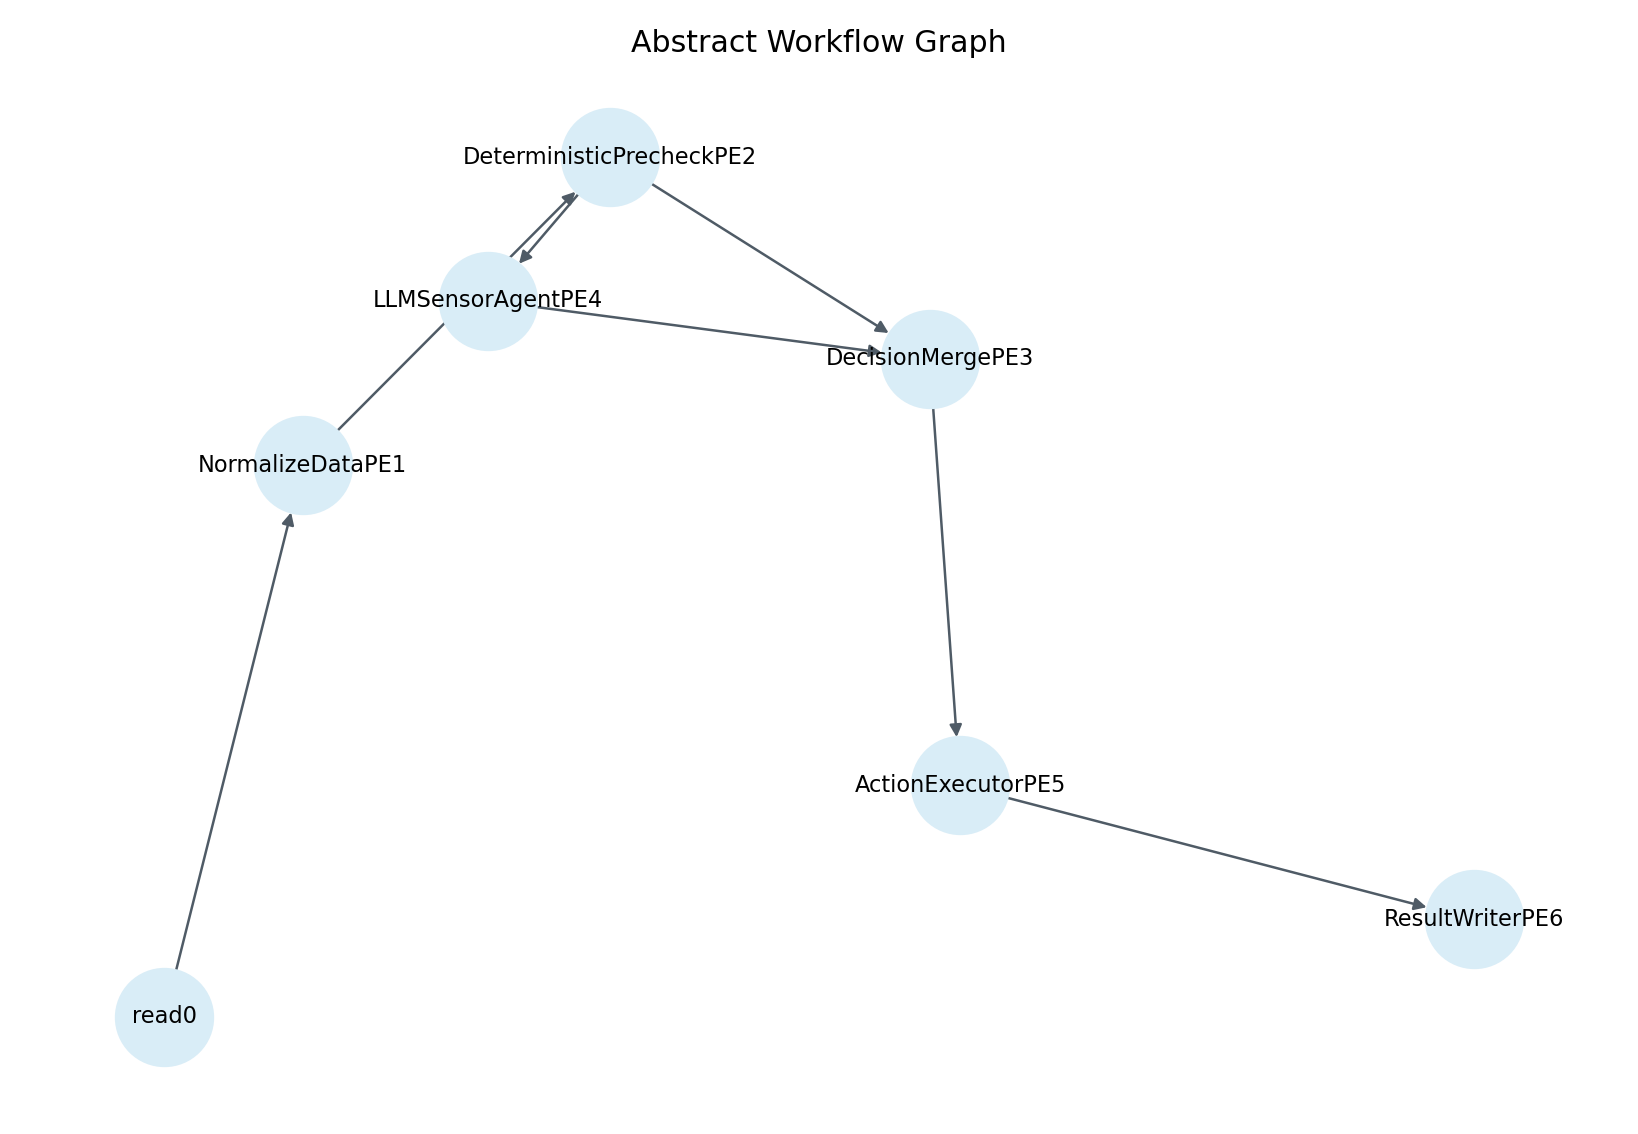

simple — concrete: monitor_concrete_graph_run20260915T213113637729Z.png


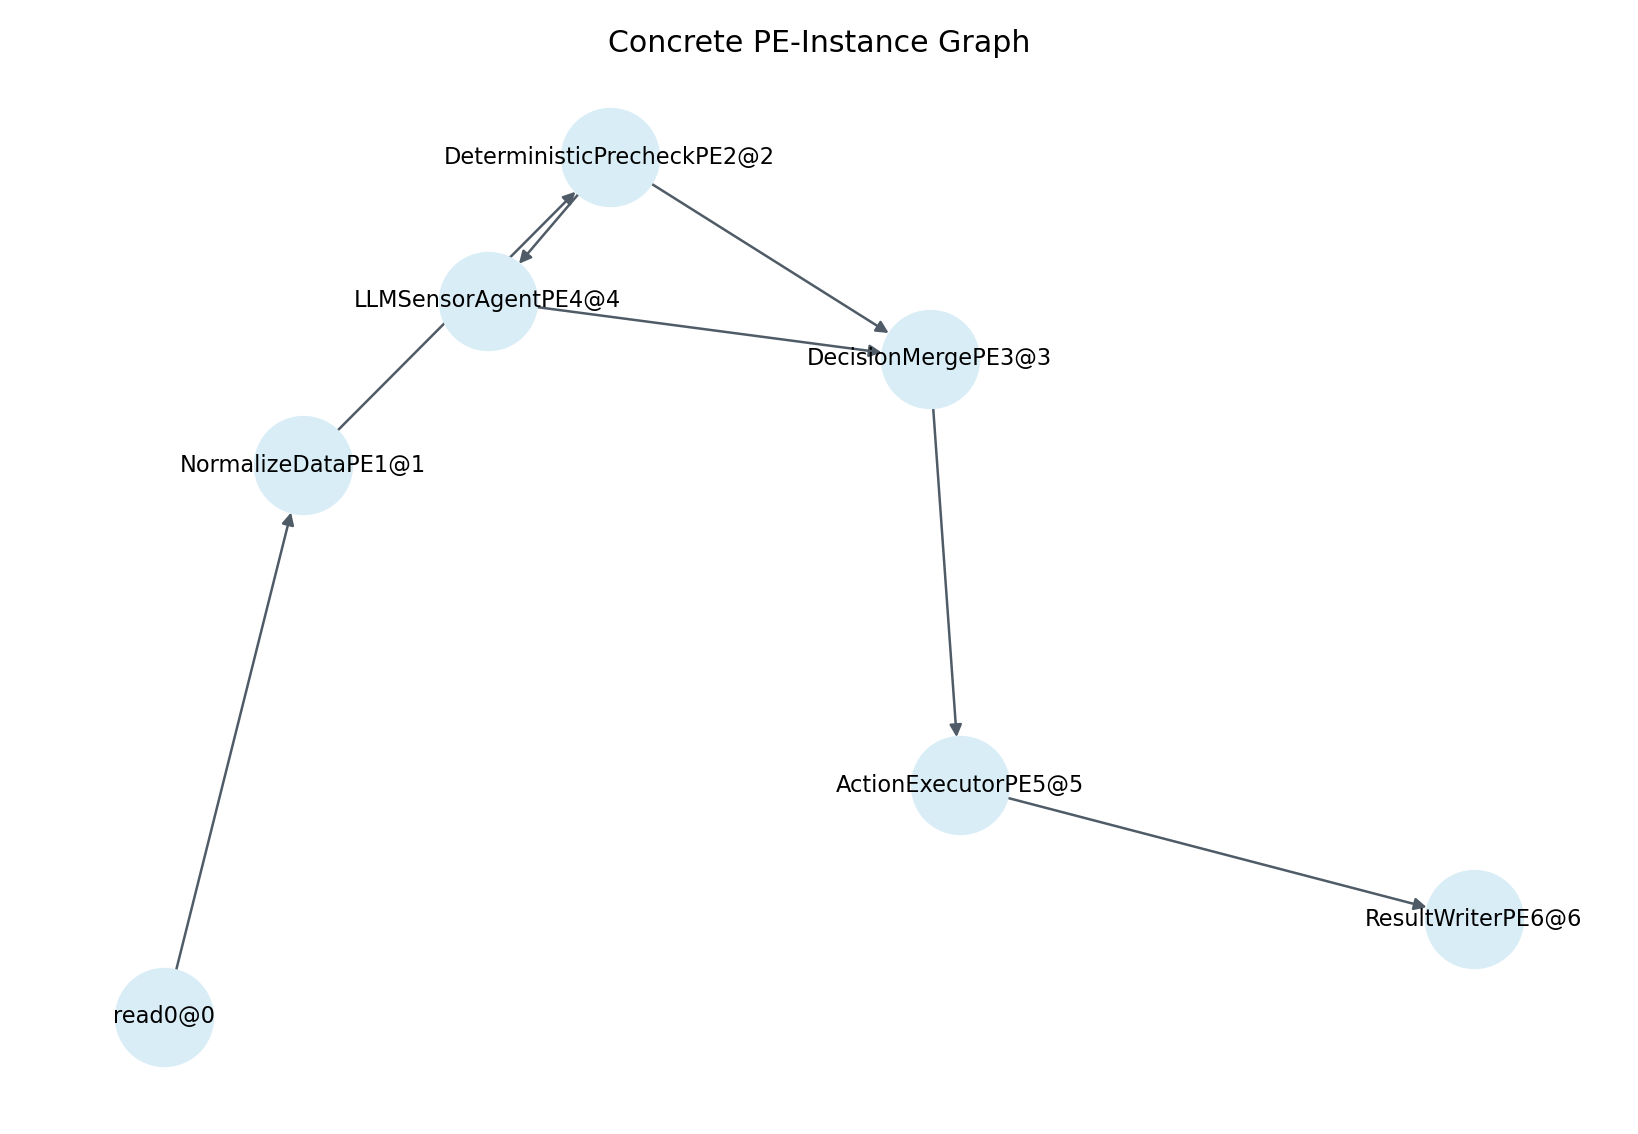

multi — abstract: monitor_abstract_graph_run20260915T213323534623Z.png


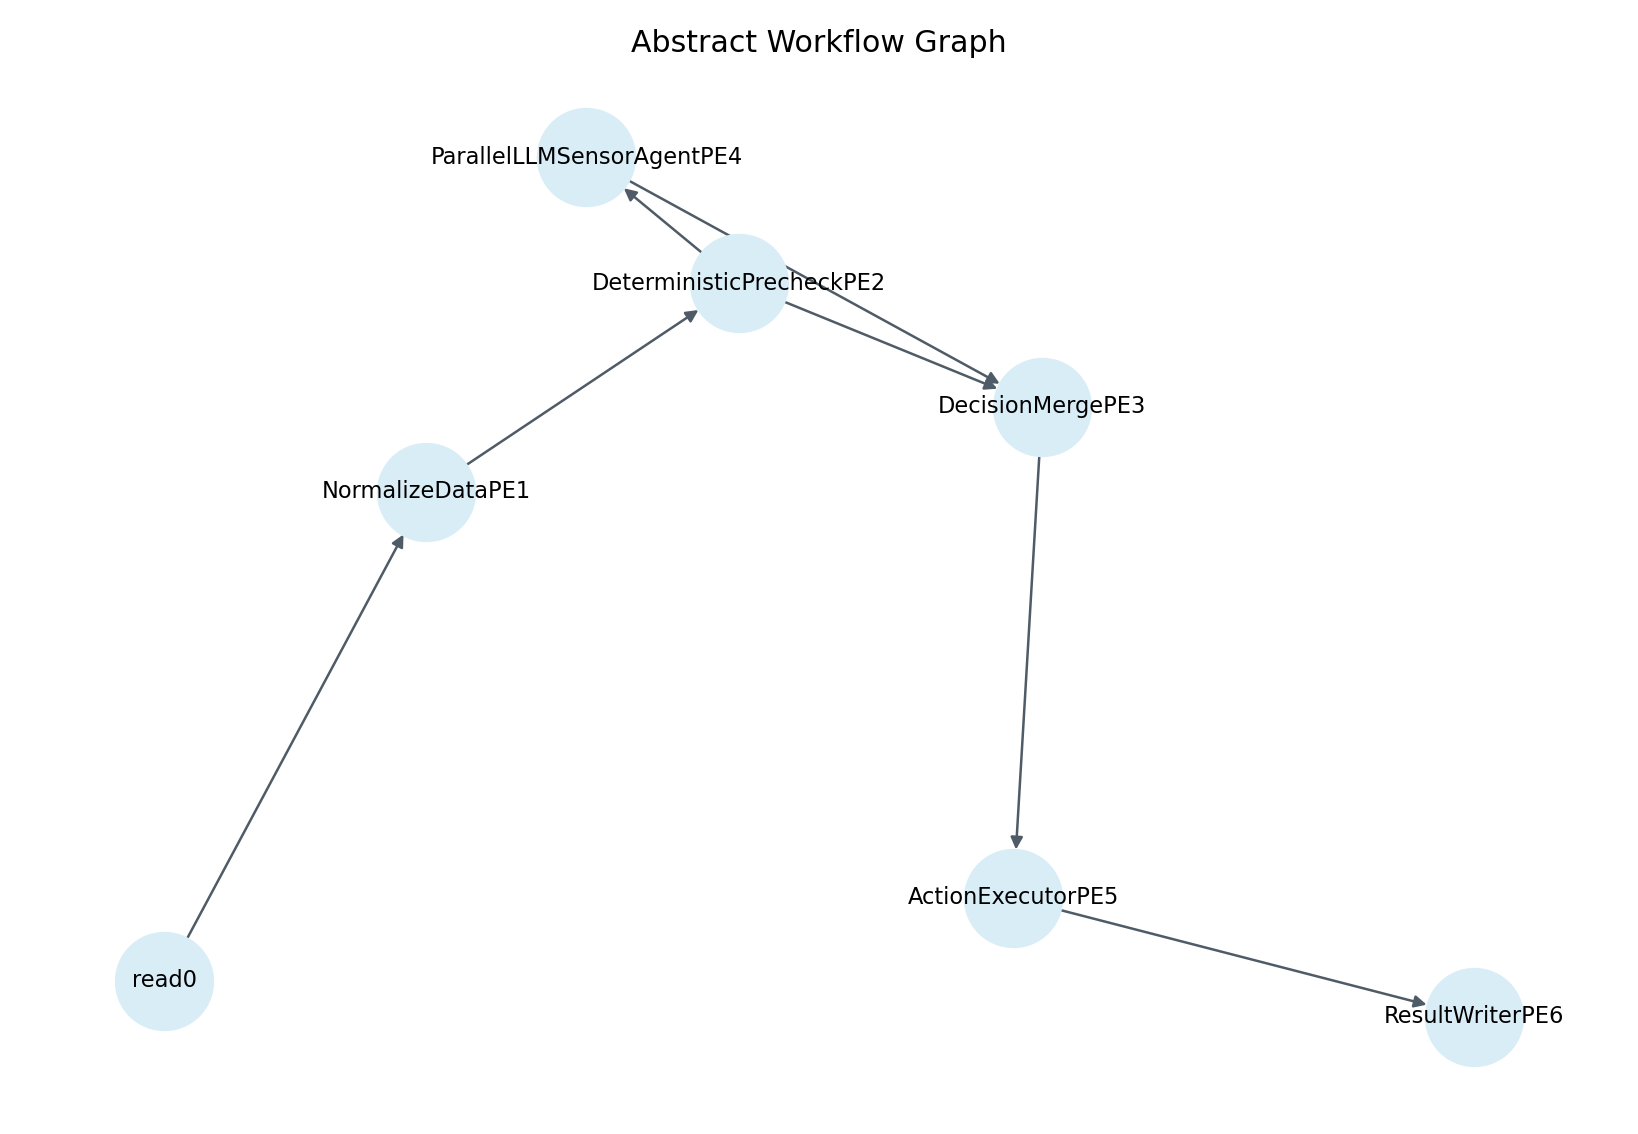

multi — concrete: monitor_concrete_graph_run20260915T213323534623Z.png


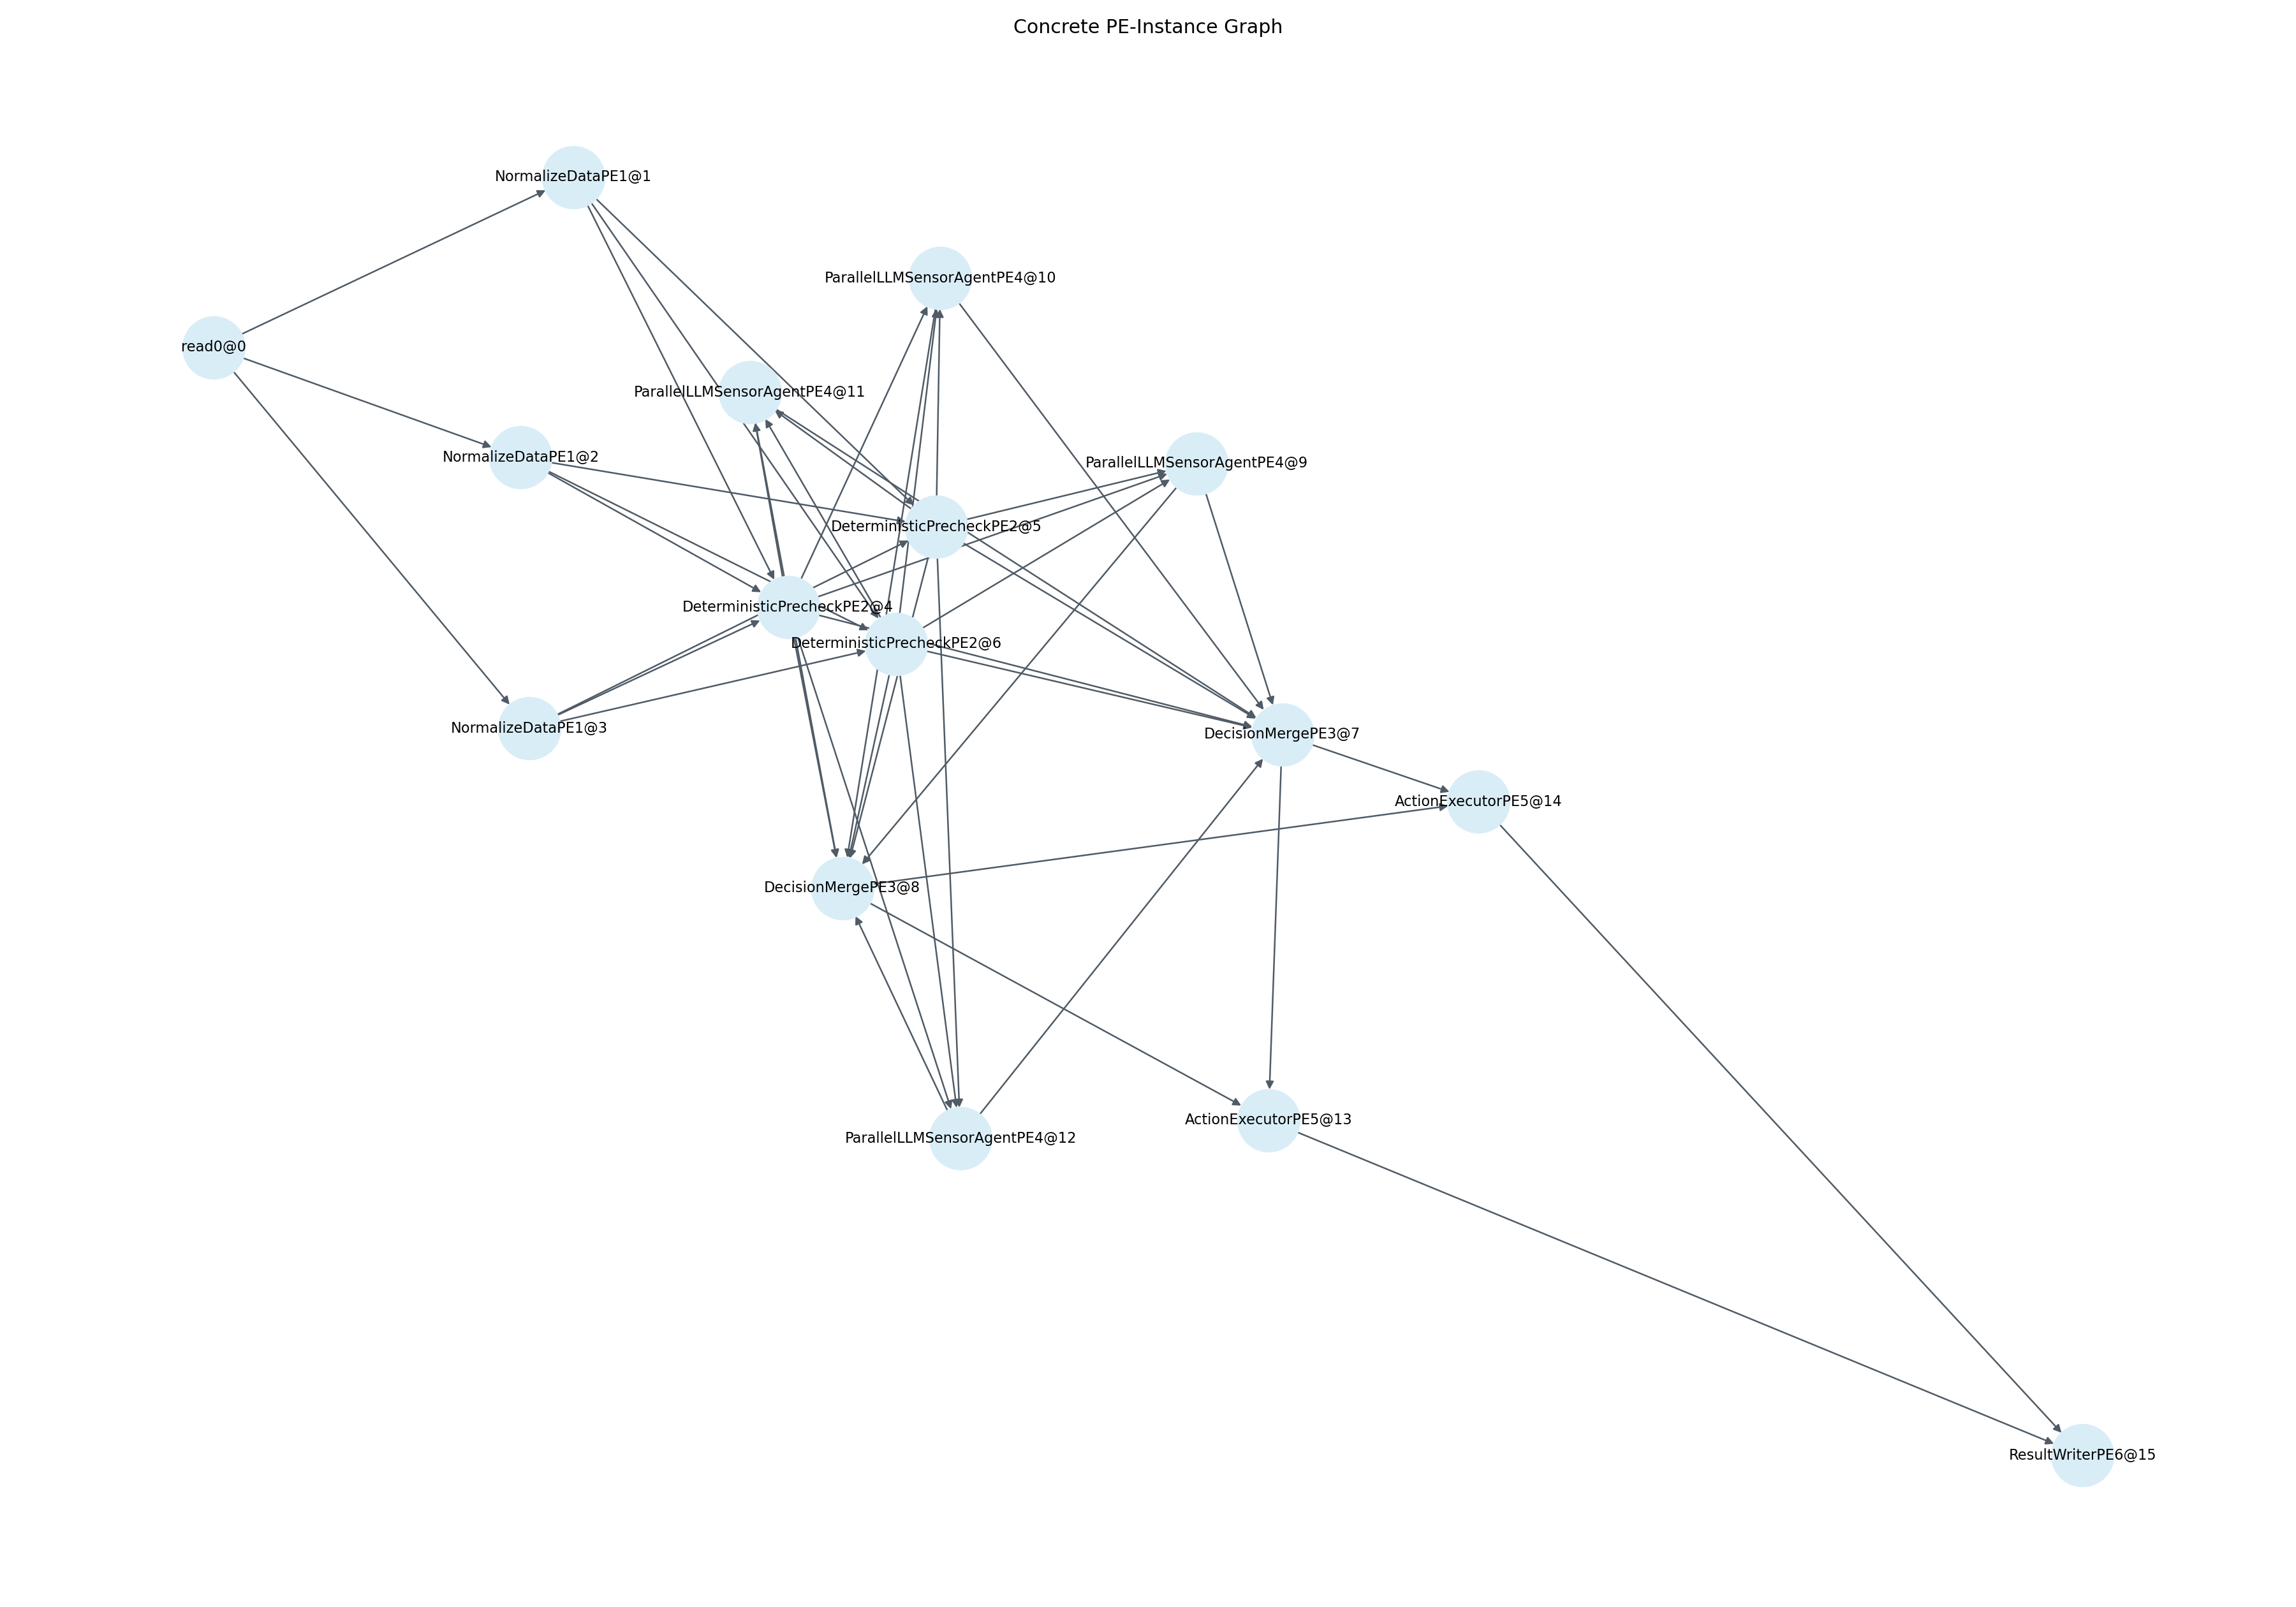

In [14]:
from IPython.display import Image, display

for label, directory in {
    "simple": "/content/results/agentic_simple",
    "multi": "/content/results/agentic_multi",
}.items():
    for kind, pattern in [("abstract", "monitor_abstract_graph_run*.png"), ("concrete", "monitor_concrete_graph_run*.png")]:
        path = newest(directory, pattern)
        if path:
            print(f"{label} — {kind}: {path.name}")
            display(Image(filename=str(path)))


## 6. Download the traces and monitoring

The first cell creates one ZIP containing both agent JSONL traces, both monitoring directories, the input data and workflow Python files. The second cell downloads it through the browser.

In [15]:
import shutil
from pathlib import Path

bundle = Path("/content/dispel4py_agentic_ai_traces")
if bundle.exists():
    shutil.rmtree(bundle)
bundle.mkdir()

for filename in [
    "agentic_sensor_results.jsonl",
    "agentic_parallel_results.jsonl",
    "sensor_data_agentic.json",
    "sensor_data_parallel_100.json",
    "sensor_workflow_agentic.py",
    "sensor_workflow_agentic_parallel.py",
]:
    shutil.copy2(Path("/content") / filename, bundle / filename)

shutil.copytree("/content/results/agentic_simple", bundle / "monitoring_simple")
shutil.copytree("/content/results/agentic_multi", bundle / "monitoring_multi")
zip_path = shutil.make_archive(str(bundle), "zip", root_dir="/content", base_dir=bundle.name)
print("Created:", zip_path)


Created: /content/dispel4py_agentic_ai_traces.zip


In [16]:
from google.colab import files
files.download("/content/dispel4py_agentic_ai_traces.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### What is inside the download

- `agentic_sensor_results.jsonl`: simple-run decisions and tool traces.
- `agentic_parallel_results.jsonl`: multi-run decisions, tools and worker IDs.
- `monitoring_simple/` and `monitoring_multi/`:
  - `monitor_summary_...csv`: summary per abstract PE.
  - `monitor_instances_...csv`: summary per concrete PE/process instance.
  - `monitor_iteration_timings_...csv`: one row per recorded iteration.
  - `monitor_iteration_timings_summary_...csv`: iteration-latency summary.
  - `monitor_shape_...json` and `monitor_concrete_shape_...json`: graph structure.
  - `monitor_abstract_graph_...png` and `monitor_concrete_graph_...png`: workflow diagrams.

The timestamped filenames identify each monitored run. Re-running after the cleanup cells replaces the corresponding run directory, which keeps the notebook output unambiguous.
